# Phase 4 — Baseline models (FD001)

Objective: establish a floor that every subsequent model (Phase 5 LightGBM, Phase 7 CNN
stretch) must beat. Implements the NASA scoring function, a naive baseline, and a linear
degradation baseline, and records both in a comparison table. See `doc/plan.md` Phase 4 for the
full spec.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; reused unchanged from Phase 3.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

## 0. Load data

Same parsing as Phases 0–3 — reload `train_df`, `test_df`, `rul_true` fresh rather than depend on
prior notebook state, matching this project's per-notebook reload convention.

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

train_df.shape, test_df.shape, rul_true.shape

((20631, 26), (13096, 26), (100,))

## 1. Capped RUL label

Recomputes the Phase 2 label — `rul = min(max_cycle - cycle, 125)` — on `train_df`. Needed here
to fit the linear-degradation baseline in Section 4 against the *capped* target, matching every
later phase rather than the raw linear countdown.

In [3]:
RUL_CAP = 125

max_cycle = train_df.groupby("engine_id")["cycle"].transform("max")
train_df["rul"] = (max_cycle - train_df["cycle"]).clip(upper=RUL_CAP)

train_df[["engine_id", "cycle", "rul"]].head()

,engine_id,cycle,rul
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


## 2. NASA scoring function

Implemented exactly to `doc/plan.md` Phase 4 Activity 1: `d = pred - true`; `exp(-d/13) - 1` for
`d < 0` (under-prediction — conservative, penalized lightly), `exp(d/10) - 1` for `d >= 0`
(over-prediction — optimistic, penalized more steeply). This must exist before any model
evaluation, since every baseline below is scored with it. An `rmse` helper is added alongside it
— not required by the plan, but needed immediately and reused identically for both baselines.

In [4]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return scores.sum()


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [5]:
# Toy sanity check: d = -10 (early / conservative prediction) should score lower than
# d = +10 (late / optimistic prediction), per the plan's specified verification step.
toy_true = np.array([100.0])
score_early = nasa_score(toy_true, toy_true - 10)  # d = -10
score_late = nasa_score(toy_true, toy_true + 10)   # d = +10

assert score_early < score_late, "early (conservative) prediction must be penalized less"
print(f"score at d=-10 (early):  {score_early:.4f}")
print(f"score at d=+10 (late):   {score_late:.4f}")
print("OK: early prediction penalized less than late prediction, as expected.")

score at d=-10 (early):  1.1581
score at d=+10 (late):   1.7183
OK: early prediction penalized less than late prediction, as expected.


## 3. Naive baseline

`RUL_pred = mean(max_cycle over training engines) - last_cycle_of_test_engine`, clipped to `>= 0`.
Predictions are reindexed to `rul_true`'s engine order before scoring.

In [6]:
mean_train_max_cycle = train_df.groupby("engine_id")["cycle"].max().mean()
test_last_cycle = test_df.groupby("engine_id")["cycle"].max()

naive_pred = (mean_train_max_cycle - test_last_cycle).clip(lower=0)
naive_pred = naive_pred.reindex(rul_true.index)

naive_rmse = rmse(rul_true.values, naive_pred.values)
naive_nasa = nasa_score(rul_true.values, naive_pred.values)

print(f"mean train max cycle: {mean_train_max_cycle:.2f}")
print(f"Naive baseline — RMSE: {naive_rmse:.2f}, NASA score: {naive_nasa:.2f}")

mean train max cycle: 206.31
Naive baseline — RMSE: 40.20, NASA score: 25527.83


## 4. Linear degradation baseline

Fit `RUL (capped) ~ cycle` per training engine on that engine's own cycles, then predict test
engines at their last cycle.

**Interpretation note on the intercept.** The plan's wording — "fit ... using that engine's own
training cycles ... predict ... using the *average slope* from training engines" — is ambiguous
about the intercept, since it only names the slope explicitly. Test engines have no RUL labels to
fit against, so there is no other source for a per-test-engine intercept. This notebook resolves
the ambiguity by averaging *both* slope and intercept across the 100 training-engine fits and
applying them as one shared line — a different reader could parse the plan text as "slope only,
per-engine intercept," but that reading is not implementable without test-set RUL, so the
shared-line interpretation is used here.

In [7]:
slopes = []
intercepts = []

for engine_id, group in train_df.groupby("engine_id"):
    slope, intercept = np.polyfit(group["cycle"], group["rul"], 1)
    slopes.append(slope)
    intercepts.append(intercept)

avg_slope = np.mean(slopes)
avg_intercept = np.mean(intercepts)

print(f"average slope:     {avg_slope:.4f}")
print(f"average intercept: {avg_intercept:.4f}")

average slope:     -0.6846
average intercept: 152.2452


In [8]:
linear_pred = (avg_slope * test_last_cycle + avg_intercept).clip(lower=0)
linear_pred = linear_pred.reindex(rul_true.index)

linear_rmse = rmse(rul_true.values, linear_pred.values)
linear_nasa = nasa_score(rul_true.values, linear_pred.values)

print(f"Linear degradation baseline — RMSE: {linear_rmse:.2f}, NASA score: {linear_nasa:.2f}")

Linear degradation baseline — RMSE: 36.30, NASA score: 17234.08


## 5. Comparison table

In [9]:
comparison = pd.DataFrame({
    "Model": ["Naive", "Linear degradation"],
    "RMSE": [naive_rmse, linear_rmse],
    "NASA score": [naive_nasa, linear_nasa],
})
comparison

,Model,RMSE,NASA score
0,Naive,40.195922,25527.834089
1,Linear degradation,36.296469,17234.080949


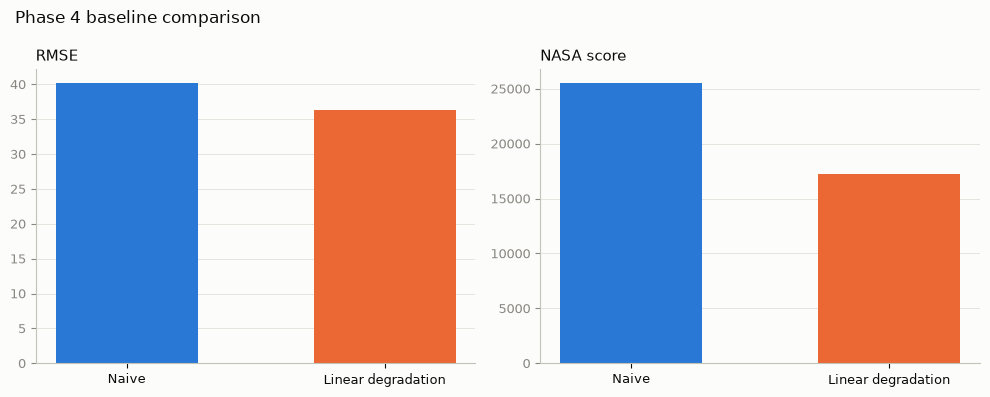

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bar_colors = CATEGORICAL_PALETTE[:2]

for ax, metric in zip(axes, ["RMSE", "NASA score"]):
    ax.bar(comparison["Model"], comparison[metric], color=bar_colors, width=0.55)
    ax.set_title(metric, fontsize=11, color=INK, loc="left")
    ax.tick_params(axis="x", colors=INK, labelsize=9)
    ax.tick_params(axis="y", colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

fig.suptitle("Phase 4 baseline comparison", fontsize=12, color=INK, x=0.02, ha="left")
fig.tight_layout()
plt.show()

## 6. Written summary

The naive baseline (predicting the training-set average end-of-life cycle minus each test
engine's last observed cycle) scores **RMSE 40.20, NASA score 25527.83**. The linear degradation
baseline (a single shared slope/intercept, averaged across all 100 per-engine fits of capped RUL
against cycle) improves on this with **RMSE 36.30, NASA score 17234.08**, landing close to the
spec's ~35-cycle floor using only `cycle` as a feature — no sensor data at all.

The NASA-score gap between the two baselines (25527.83 -> 17234.08, a ~32% drop) is
proportionally larger than the RMSE gap (40.20 -> 36.30, a ~10% drop). This is consistent with
the exponential penalty's asymmetry: the naive baseline makes more large *optimistic* misses
(over-predicting RUL, `d >= 0`) than the linear baseline does, and those errors are penalized
on the steeper `exp(d/10)` branch — so the NASA score reacts more strongly than RMSE to the same
reduction in error, exactly the asymmetric-penalty rationale from `doc/requirements_spec.md` §4.2.

Both baselines are recorded in the comparison table above, ready for a third row (LightGBM) in
Phase 6. The linear baseline's 36.30 RMSE is the number every later model must beat.